
1- load the saved testing data

In [97]:
import pandas as pd
# Load from pickle

X_test = pd.read_pickle('X_test.pkl')
y_test = pd.read_pickle('y_test.pkl')

2- Load the parameters, transformers, and functions used to clean the training and validation data, to use them to preprocess the test data

In [100]:
# Library needed to load this type of file
import pickle
import dill

# Load the saved preprocessing objects
with open('scaler.pkl', 'rb') as file:
    transformer_scale = pickle.load(file)

with open('numerical_imputer.pkl', 'rb') as file:
    numerical_imputer = pickle.load(file)

with open('categorical_imputer.pkl', 'rb') as file:
    categorical_imputer = pickle.load(file)

with open('label_encoder_sex.pkl', 'rb') as file:
    transformer_label_encoder_sex = pickle.load(file)

with open('label_encoder_smoker.pkl', 'rb') as file:
    transformer_label_encoder_smoker = pickle.load(file)

with open('one_hot_encoder_region.pkl', 'rb') as file:
    transformer_one_hot_encoder_region = pickle.load(file)

# Load the function from the file
with open('remove_outliers.pkl', 'rb') as file:
    remove_outliers = dill.load(file)

with open('clean_categorical_typos.pkl', 'rb') as file:
    clean_categorical_typos = dill.load(file)
    
with open('binary_encoding.pkl', 'rb') as file:
    binary_encoding = dill.load(file)

with open('one_hot_encoding.pkl', 'rb') as file:
    one_hot_encoding = dill.load(file)

# Load the medians from a pickle file
with open("medians.pkl", "rb") as file:
    medians = pickle.load(file)

3- Apply the saved transformers to the test dataset to clean it

In [103]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, LabelEncoder

def preprocessing_test(test_data, y_test, transformer_label_encoder_sex, transformer_label_encoder_smoker,
                       transformer_one_hot_encoder_region, numerical_imputer, categorical_imputer, transformer_scale, medians):
    test_data_cp = test_data.copy()

    # Convert y_test to a DataFrame to handle outliers (same as validation)
    y_test_df = pd.DataFrame(y_test, columns=["charges"])
    
    numerical_cols = ['age', 'bmi', 'children']
    categorical_cols = ['sex', 'smoker', 'region']

    # Imputation using transformers already fitted during training (do not re-fit)
    test_data_cp[numerical_cols] = numerical_imputer.transform(test_data_cp[numerical_cols])
    test_data_cp[categorical_cols] = categorical_imputer.transform(test_data_cp[categorical_cols])

    
    # Clean outliers for testing data and replace it with the median of the column
    for col in numerical_cols:
        test_data_cp = remove_outliers(test_data_cp, col, median_value=medians[col])


    # Clean categorical typos for testing data
    for col in categorical_cols:
        test_data_cp = clean_categorical_typos(test_data_cp, col)

    # Clean outliers in y_test (charges), if necessary
    y_test_df = remove_outliers(y_test_df, "charges", median_value=medians["charges"])

    # Scaling using the already trained scaler (no recalculation)
    test_data_cp = transformer_scale.transform(test_data_cp)
    test_data_cp = pd.DataFrame(test_data_cp, columns=numerical_cols + categorical_cols)

    # Encoding using the trained transformers (do not re-fit)
    test_data_cp = binary_encoding(test_data_cp, 'sex', transformer_label_encoder_sex)
    test_data_cp = binary_encoding(test_data_cp, 'smoker', transformer_label_encoder_smoker)
    test_data_cp = one_hot_encoding(test_data_cp, 'region', transformer_one_hot_encoder_region)

    # Convert y_test_df back to Series for consistency in return type
    y_test_processed = y_test_df["charges"]

    return test_data_cp, y_test_processed


In [105]:
X_test_transformed, y_test_transformed = preprocessing_test(X_test, y_test, transformer_label_encoder_sex, transformer_label_encoder_smoker, transformer_one_hot_encoder_region, numerical_imputer, categorical_imputer, transformer_scale, medians)

In [107]:
X_test_transformed

,age,bmi,children,sex,smoker,region_northeast,region_northwest,region_southeast,region_southwest
0,0.326087,0.515584,1.0,1,0,0.0,0.0,1.0,0.0
1,0.630435,0.268104,0.4,1,0,1.0,0.0,0.0,0.0
2,0.326087,0.232439,0.0,0,0,0.0,0.0,1.0,0.0
3,0.304348,0.409831,0.2,1,0,0.0,0.0,1.0,0.0
4,0.543478,0.198015,0.0,1,0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...
109,0.108696,0.346875,0.0,0,0,0.0,0.0,0.0,1.0
110,0.021739,0.55466,0.4,0,1,0.0,0.0,0.0,1.0
111,0.043478,0.700419,0.4,1,1,0.0,0.0,0.0,1.0
112,0.891304,0.306404,0.6,0,0,0.0,1.0,0.0,0.0


In [109]:
y_test_transformed

906      6653.78860
888      9225.25640
1027     4185.09790
220      4074.45370
416      6250.43500
           ...     
822     13126.67745
858     36397.57600
439     38344.56600
591     14382.70905
390     10407.08585
Name: charges, Length: 114, dtype: float64

4- Load the trained model

In [112]:
from tensorflow import keras
loaded_model = keras.models.load_model('trained_model.keras')
# Display a summary of the model
loaded_model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_30 (Dense)                │ (None, 512)            │         5,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 347,012 (1.32 MB)

 Trainable params: 173,505 (677.75 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 173,507 (677.77 KB)

5- Use the trained model to predict charges in the test data

In [115]:
predictions = loaded_model.predict(X_test_transformed)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


6- Evaluate and print the mean absolute error.

In [118]:
test_loss, test_mae = loaded_model.evaluate(X_test_transformed, y_test_transformed)

print(f'Mean Absolute Error (MAE) on the test set: {test_mae:.4f}')

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2007.6191 - mae: 2007.6191  
Mean Absolute Error (MAE) on the test set: 2340.7495


7- Print the real charges and the predicted charges.

In [121]:
for actual, pred in zip (y_test_transformed, predictions):
    print(f'Actual: {actual}, pred: {pred}') 

Actual: 6653.7886, pred: [6908.4717]
Actual: 9225.2564, pred: [9276.923]
Actual: 4185.0979, pred: [4894.661]
Actual: 4074.4537, pred: [4013.6904]
Actual: 6250.435, pred: [6210.7607]
Actual: 5240.765, pred: [5260.8486]
Actual: 10806.839, pred: [10794.31]
Actual: 14119.62, pred: [14364.53]
Actual: 8871.1517, pred: [8666.899]
Actual: 18972.495, pred: [19057.408]
Actual: 47403.88, pred: [48528.113]
Actual: 11837.16, pred: [11943.168]
Actual: 3537.703, pred: [4360.707]
Actual: 18033.9679, pred: [17351.38]
Actual: 8124.4084, pred: [8122.1045]
Actual: 19144.57652, pred: [8222.68]
Actual: 21344.8467, pred: [2139.649]
Actual: 11658.11505, pred: [11582.042]
Actual: 2457.502, pred: [1945.6633]
Actual: 9432.9253, pred: [13097.481]
Actual: 6186.127, pred: [5786.2656]
Actual: 36837.467, pred: [37792.4]
Actual: 7153.5539, pred: [7323.409]
Actual: 2585.85065, pred: [2989.8027]
Actual: 9447.3824, pred: [9263.677]
Actual: 11741.726, pred: [11808.124]
Actual: 1121.8739, pred: [1258.8187]
Actual: 2498.414

8- Display a scatter plot to compare between predicted and actual charges.

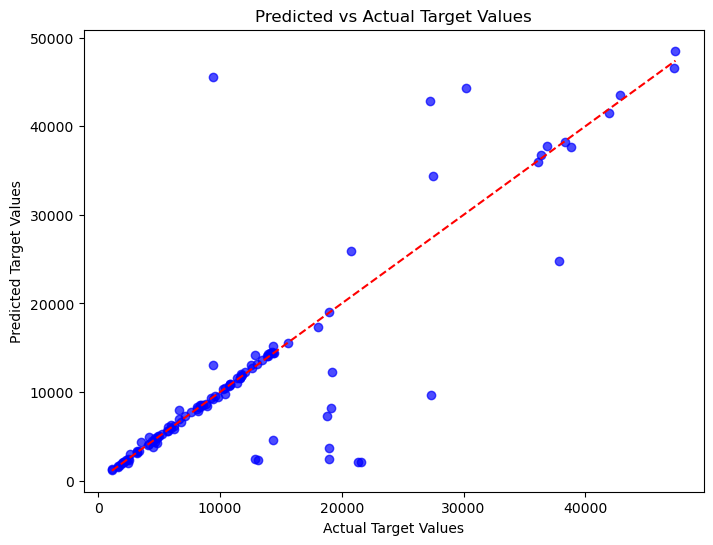

In [124]:
import matplotlib.pyplot as plt

# Create a scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test_transformed, predictions, color='blue', alpha=0.7)

# Add a line for perfect predictions (where predicted == actual)
plt.plot([min(y_test_transformed), max(y_test_transformed)], [min(y_test_transformed), max(y_test_transformed)], color='red', linestyle='--')

# Add labels and title
plt.xlabel('Actual Target Values')
plt.ylabel('Predicted Target Values')
plt.title('Predicted vs Actual Target Values')

# Show the plot
plt.show()